In [1]:
# from tqdm import trange
# from tqdm.notebook import tqdm, trange
# from numpy.fft import fft2, fftfreq, fftshift, ifft2
# from typing import List
# from functools import partial
# import sys
# import itertools
# from gdsfactory.get_netlist import get_netlist as _get_netlist
# from pprint import pprint
# from omegaconf import OmegaConf
import numpy as np
# from sklearn.linear_model import LinearRegression
# from scipy.constants import c
# from gdsfactory.simulation.get_sparameters_path import get_sparameters_path_lumerical
import gdsfactory as gf
import matplotlib.pyplot as plt
import sax

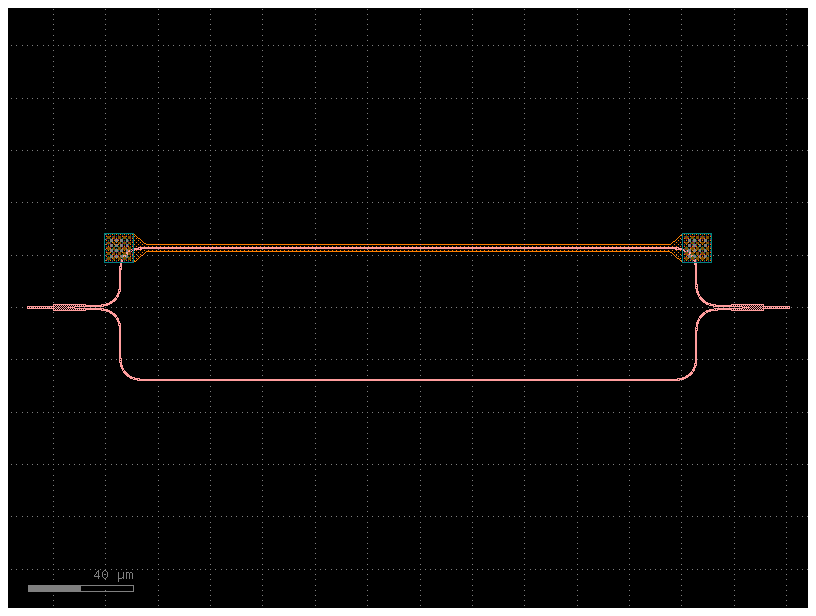

In [2]:
delta_length = 10
mzi_component = gf.components.mzi_phase_shifter_top_heater_metal(
    delta_length=delta_length
)
fig = mzi_component.plot()

def straight(wl=1.5, length=10.0, neff=2.4):
    wl0 = 1.5  # center wavelength for which the waveguide model is defined
    return sax.reciprocal({("o1", "o2"): np.exp(2j * np.pi * neff * length / wl)})


def mmi1x2():
    """Returns a perfect 1x2 splitter."""
    return sax.reciprocal(
        {
            ("o1", "o2"): 0.5**0.5,
            ("o1", "o3"): 0.5**0.5,
        }
    )


def bend_euler(wl=1.5, length=20.0):
    """Returns bend Sparameters with reduced transmission compared to a straight."""
    return {k: 0.99 * v for k, v in straight(wl=wl, length=length).items()}


class phase_shifter_heater_alex:
    def __init__(self,
        wl: float = 1.55,
        neff: float = 2.34,
        length: float = 10,
        loss: float = 0.0,
        voltage = 0,
    ):
        self.wl = wl
        self.neff = neff
        self.length = length
        self.loss = loss
        self.voltage = voltage
        self.count = 0

    def __call__(self):
        """Returns simple phase shifter model"""
        deltaphi = self.voltage * np.pi
        phase = 2 * np.pi * self.neff * self.length / self.wl + deltaphi
        amplitude = np.asarray(10 ** (-self.loss * self.length / 20), dtype=complex)
        transmission = amplitude * np.exp(1j * phase)
        sdict = sax.reciprocal(
            {
                ("o1", "o2"): transmission,
            }
        )
        return sdict

class phase_shifter_heater:
    def __init__(
        self,
        wl: float = 1.55,
        neff: float = 2.34,
        length: float = 10,
        loss: float = 0.0,
        voltage=0,
        count=0,
    ):
        self.wl = wl
        self.neff = neff
        self.length = length
        self.loss = loss
        self.voltage = voltage
        self.count = count

    def __call__(self, wl=1.55, voltage=0):
        """Returns simple phase shifter model"""
        self.wl = wl
        self.voltage = voltage

        deltaphi = self.voltage * np.pi
        phase = 2 * np.pi * self.neff * self.length / self.wl + deltaphi
        amplitude = np.asarray(10 ** (-self.loss * self.length / 20), dtype=complex)
        transmission = amplitude * np.exp(1j * phase)
        sdict = sax.reciprocal(
            {
                ("o1", "o2"): transmission,
            }
        )
        self.count += 1
        return sdict

class phase_shifter_heater_empty_sig:
    def __init__(
        self,
        wl: float = 1.55,
        neff: float = 2.34,
        length: float = 10,
        loss: float = 0.0,
        voltage=0,
        count=0,
    ):
        self.wl = wl
        self.neff = neff
        self.length = length
        self.loss = loss
        self.voltage = voltage
        self.count = count

    def __call__(self):
        """Returns simple phase shifter model"""
        deltaphi = self.voltage * np.pi
        phase = 2 * np.pi * self.neff * self.length / self.wl + deltaphi
        amplitude = np.asarray(10 ** (-self.loss * self.length / 20), dtype=complex)
        transmission = amplitude * np.exp(1j * phase)
        sdict = sax.reciprocal(
            {
                ("o1", "o2"): transmission,
            }
        )
        self.count += 1
        return sdict



In [3]:
models = {
    "bend_euler": bend_euler,
    "mmi1x2": mmi1x2,
    "straight": straight,
    "straight_heater_metal_undercut": phase_shifter_heater,
}

mzi_component = gf.components.mzi_phase_shifter_top_heater_metal(
    delta_length=delta_length
)
netlist = mzi_component.get_netlist()
mzi_circuit, temp = sax.circuit(netlist=netlist, models=models, ignore_missing_ports=True)

example = {"sxt":{"voltage":0}}
mzi_circuit(sxt = {"voltage": 0})
mzi_circuit(**{"sxt":{"voltage":0}})

S = mzi_circuit(wl=1.55)
S



{('o1', 'o1'): Array(0.+0.j, dtype=complex128),
 ('o1', 'o2'): Array(-0.62067471+0.70718949j, dtype=complex128),
 ('o2', 'o1'): Array(-0.62067471+0.70718949j, dtype=complex128),
 ('o2', 'o2'): Array(0.+0.j, dtype=complex128)}

In [5]:
models_empty_sig = {
    "bend_euler": bend_euler,
    "mmi1x2": mmi1x2,
    "straight": straight,
    "straight_heater_metal_undercut": phase_shifter_heater_empty_sig,
}

mzi_circuit_empty_sig, temp = sax.circuit(netlist=netlist, models=models_empty_sig, ignore_missing_ports=True)

try:
    mzi_circuit_empty_sig(sxt = {"voltage": 0})
except Exception as e:
    print(e)

# S_empty_sig = mzi_circuit_empty_sig(wl=1.55)
# S_empty_sig

phase_shifter_heater_empty_sig.__call__() got an unexpected keyword argument 'voltage'


Okay, so sax.circuit returns a flat_circuit. A flat circuit returns a _circuit function which can take as input 

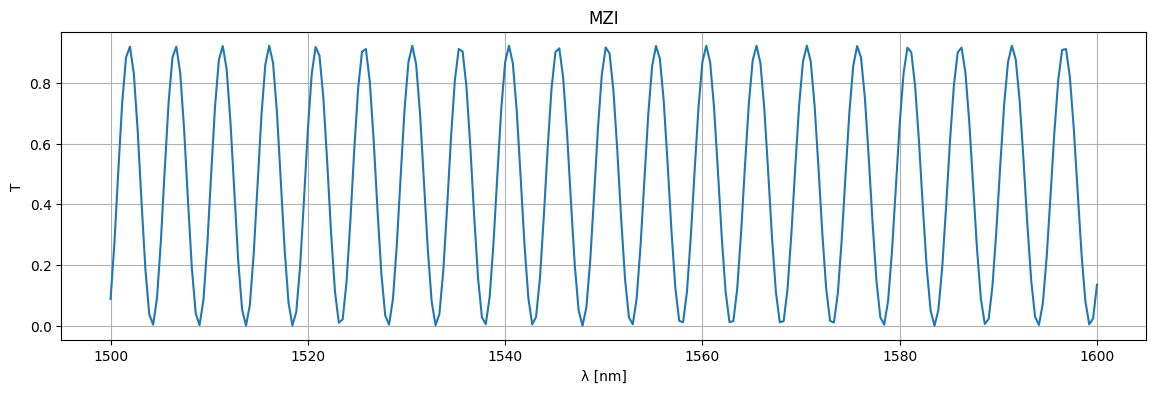

In [6]:
wl = np.linspace(1.5, 1.6, 256)
S = mzi_circuit(wl=wl)

plt.figure(figsize=(14, 4))
plt.title("MZI")
plt.plot(1e3 * wl, np.abs(S["o1", "o2"]) ** 2)
plt.xlabel("λ [nm]")
plt.ylabel("T")
plt.grid(True)
plt.show()

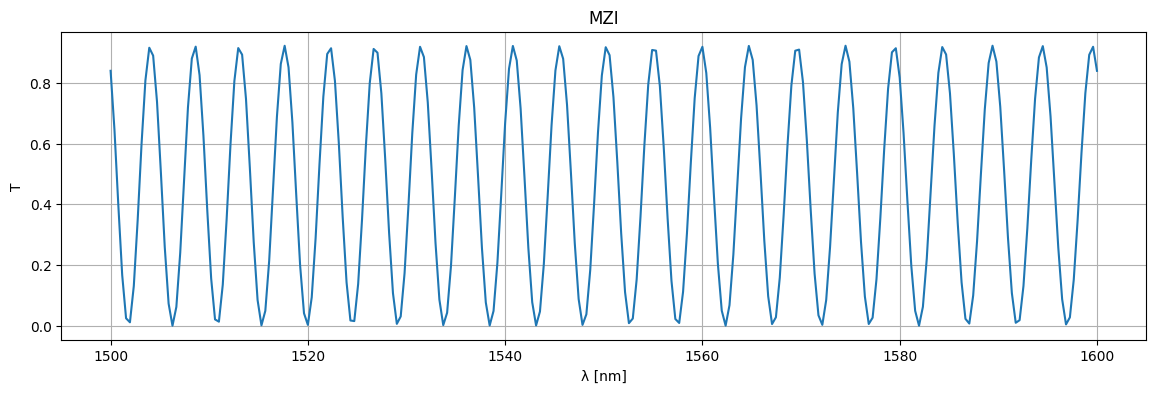

In [7]:
S = mzi_circuit_empty_sig(wl=wl)

plt.figure(figsize=(14, 4))
plt.title("MZI")
plt.plot(1e3 * wl, np.abs(S["o1", "o2"]) ** 2)
plt.xlabel("λ [nm]")
plt.ylabel("T")
plt.grid(True)
plt.show()

`mzi_circuit` and `mzi_circuit_empty_sig` gave different plots!!!

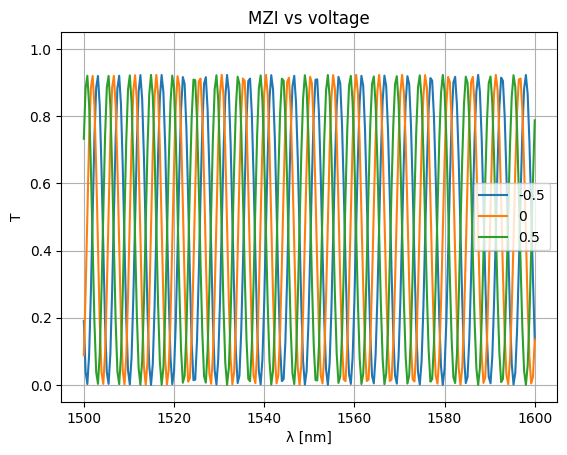

In [8]:
voltages = np.linspace(-1, 1, num=5)
voltages = [-0.5, 0, 0.5]

for voltage in voltages:
    S = mzi_circuit(
        wl=wl,
        sxt={"voltage": voltage},
    )
    plt.plot(wl * 1e3, abs(S["o1", "o2"]) ** 2, label=str(voltage))
    plt.xlabel("λ [nm]")
    plt.ylabel("T")
    plt.ylim(-0.05, 1.05)
    plt.grid(True)

plt.title("MZI vs voltage")
plt.legend()

In [10]:
try:
    for voltage in voltages:
        S = mzi_circuit_empty_sig(
            wl=wl,
            sxt={"voltage": voltage},
        )
        plt.plot(wl * 1e3, abs(S["o1", "o2"]) ** 2, label=str(voltage))
        plt.xlabel("λ [nm]")
        plt.ylabel("T")
        plt.ylim(-0.05, 1.05)
        plt.grid(True)

    plt.title("MZI vs voltage")
    plt.legend()
except Exception as e:
    print(e)

phase_shifter_heater_empty_sig.__call__() got an unexpected keyword argument 'voltage'


`mzi_circuit` and `mzi_circuit_empty_sig` gave different plots!!!

## Can a component have memory? Create a version of the phase shifter which stores all prior voltages in a list and averages over them as an example

In [11]:
models = {
    "bend_euler": bend_euler,
    "mmi1x2": mmi1x2,
    "straight": straight,
    "straight_heater_metal_undercut": phase_shifter_heater,
}
mzi_component = gf.components.mzi_phase_shifter_top_heater_metal(
    delta_length=delta_length
)
netlist = mzi_component.get_netlist()
#Creating the circuit
mzi_circuit, circuit_info = sax.circuit(netlist=netlist, models=models, ignore_missing_ports=True)
# print(mzi_circuit)
# print(temp)

# print(dir(mzi_circuit))
# print(mzi_circuit.__call__())

S1
S2


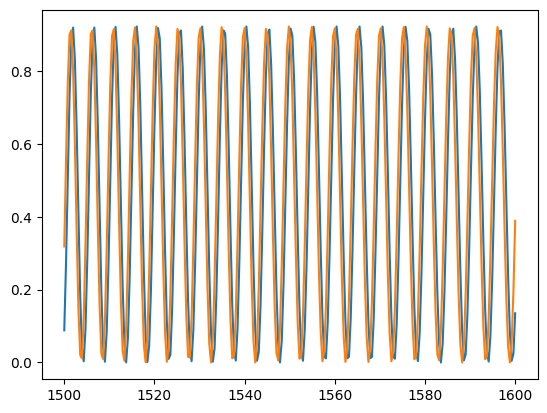

In [12]:
plt.figure()
# sax.circuit.evaluate_circuit()
from sax.backends import circuit_backends
evaluate_circuit = circuit_backends['default']

print("S1")
S1 = mzi_circuit(wl=wl,sxt={"voltage": 0.0},)
print("S2")
S2 = mzi_circuit(wl=wl,sxt={"voltage": 0.2},)
plt.plot(wl * 1e3, abs(S1["o1", "o2"]) ** 2)
plt.plot(wl * 1e3, abs(S2["o1", "o2"]) ** 2)

In [13]:
# Compare the shape of S1 and S2
for key in S1.keys():
    assert S1[key].shape == S2[key].shape, f"Shape mismatch for key {key}: {S1[key].shape} != {S2[key].shape}"

print("All shapes match between S1 and S2.")

All shapes match between S1 and S2.


In [14]:
# Elementwise comparison between S1 and S2
comparison_results = {}
for key in S1.keys():
    comparison_results[key] = np.allclose(S1[key], S2[key])

# Print the comparison results
for key, result in comparison_results.items():
    print(f"Comparison for {key}: {result}")

Comparison for ('o1', 'o1'): True
Comparison for ('o1', 'o2'): False
Comparison for ('o2', 'o1'): False
Comparison for ('o2', 'o2'): True


So it is a problem that the phase shifter is not sensitive to the voltage change between S1 and S2.

In [16]:
try:
    models = {
        "bend_euler": bend_euler,
        "mmi1x2": mmi1x2,
        "straight": straight,
        "straight_heater_metal_undercut": phase_shifter_heater_empty_sig,
    }
    mzi_component = gf.components.mzi_phase_shifter_top_heater_metal(
        delta_length=delta_length
    )
    netlist = mzi_component.get_netlist()
    mzi_circuit, circuit_info = sax.circuit(netlist=netlist, models=models, ignore_missing_ports=True)

    plt.figure()
    # sax.circuit.evaluate_circuit()
    from sax.backends import circuit_backends
    evaluate_circuit = circuit_backends['default']

    print("S1")
    S1 = mzi_circuit(wl=wl,sxt={"voltage": 0.0},)
    print("S2")
    S2 = mzi_circuit(wl=wl,sxt={"voltage": 0.2},)
    plt.plot(wl * 1e3, abs(S1["o1", "o2"]) ** 2)
    plt.plot(wl * 1e3, abs(S2["o1", "o2"]) ** 2)

    # Compare the shape of S1 and S2
    for key in S1.keys():
        assert S1[key].shape == S2[key].shape, f"Shape mismatch for key {key}: {S1[key].shape} != {S2[key].shape}"

    print("All shapes match between S1 and S2.")

    # Elementwise comparison between S1 and S2
    comparison_results = {}
    for key in S1.keys():
        comparison_results[key] = np.allclose(S1[key], S2[key])

    # Print the comparison results
    for key, result in comparison_results.items():
        print(f"Comparison for {key}: {result}")
except Exception as e:
    print(e)

S1
phase_shifter_heater_empty_sig.__call__() got an unexpected keyword argument 'voltage'


<Figure size 640x480 with 0 Axes>

Further investigation revealed the problem that stems from the tension between Jax's requirement of pure function only and the need to store state in the circuit. Sax's code that builds the circuit assumes that the models are pure functions.

There are two ways to solve this problem:
1. As seen in Pytorch and Flax, an class can be used to store the state of a model and a `__call__` function can be used to update the state and return the output. 
2. The state is stored in a standalone object and pass the state object through simulation steps of the circuit -- e.g., through use of `jax.lax.scan`.

The first approach will require a small change to the Sax's circuit constructor (see 3fe4cdec50564c6ccb8d299f1fef024ae3b61f99). We look at how it can be used here:

In [17]:
from sax.stax_types import StatefulModelBuilder

class phase_shifter_heater_builder(StatefulModelBuilder):
    def __init__(self):
        # state initialization
        self.count = 0

    def __call__(
        self,
        wl: float = 1.55,
        neff: float = 2.34,
        length: float = 10,
        loss: float = 0.0,
        voltage=0,
    ):
        """Returns simple phase shifter model"""

        deltaphi = voltage * np.pi
        phase = 2 * np.pi * neff * length / wl + deltaphi
        amplitude = np.asarray(10 ** (-loss * length / 20), dtype=complex)
        transmission = amplitude * np.exp(1j * phase)
        sdict = sax.reciprocal(
            {
                ("o1", "o2"): transmission,
            }
        )

        self.count += 1
        print(f"count={self.count}")

        return sdict

In [20]:
models = {
    "bend_euler": bend_euler,
    "mmi1x2": mmi1x2,
    "straight": straight,
    "straight_heater_metal_undercut": phase_shifter_heater_builder,
}

mzi_component = gf.components.mzi_phase_shifter_top_heater_metal(
    delta_length=delta_length
)
netlist = mzi_component.get_netlist()

mzi_circuit, cir_info = sax.circuit(
    netlist=netlist,
    models=models,
    ignore_missing_ports=True,
)

count=1


`count=1` shows us that the state is updated once as the circuit is being constructed. This is expected as Sax needs to call the model function once to get the shape of the S-matrix.

In [21]:
mzi_circuit(sxt={"voltage": 0})

count=2


{('o1', 'o1'): Array(0.+0.j, dtype=complex128),
 ('o1', 'o2'): Array(0.52664054-0.77974599j, dtype=complex128),
 ('o2', 'o1'): Array(0.52664054-0.77974599j, dtype=complex128),
 ('o2', 'o2'): Array(0.+0.j, dtype=complex128)}

From this point on, each call to `mzi_circuit` will update the `count` state of the phase shifter. 

In [22]:
S = mzi_circuit(wl=1.55)
S

count=3


{('o1', 'o1'): Array(0.+0.j, dtype=complex128),
 ('o1', 'o2'): Array(-0.15452351+0.71229167j, dtype=complex128),
 ('o2', 'o1'): Array(-0.15452351+0.71229167j, dtype=complex128),
 ('o2', 'o2'): Array(0.+0.j, dtype=complex128)}

count=4


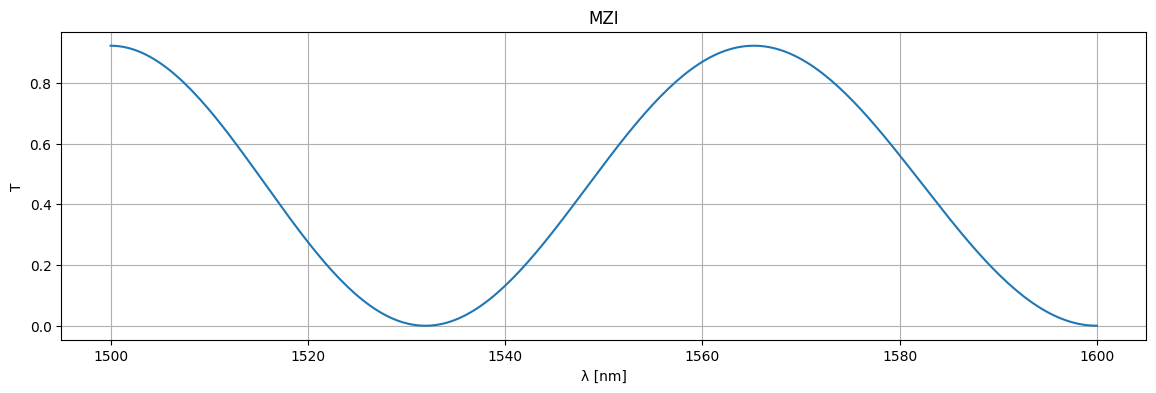

In [23]:
wl = np.linspace(1.5, 1.6, 256)
S = mzi_circuit(wl=wl)

plt.figure(figsize=(14, 4))
plt.title("MZI")
plt.plot(1e3 * wl, np.abs(S["o1", "o2"]) ** 2)  # type: ignore
plt.xlabel("λ [nm]")
plt.ylabel("T")
plt.grid(True)
plt.show()


The `count` state is updated only once even when a range of `wl` parameters are passed to the circuit. This is because the `count` state is updated only once when the `mzi_circuit` is called -- the `wl` parameter is customized to a single `numpy.array` which in turn calls the model builder's `__call__` only once to build a model.

count=5
count=6
count=7


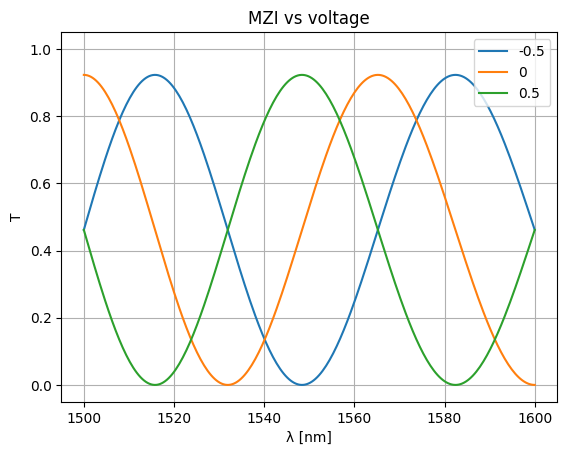

In [24]:
voltages = np.linspace(-1, 1, num=5)
voltages = [-0.5, 0, 0.5]

for voltage in voltages:
    S = mzi_circuit(
        wl=wl,
        sxt={"voltage": voltage},
    )
    plt.plot(wl * 1e3, abs(S["o1", "o2"]) ** 2, label=str(voltage))  # type: ignore
    plt.xlabel("λ [nm]")
    plt.ylabel("T")
    plt.ylim(-0.05, 1.05)
    plt.grid(True)

plt.title("MZI vs voltage")
plt.legend()